## 1D On-Center Model

Import utils

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..')) 
from lib.utils import *

1. Build net


In [2]:

#np.random.seed(seed=187)

#############################
#          Params           #
#############################

N_L0_E = 5000
N_L0_I = 5000
N_L1 = 5000

sig = 0.00001
K = 1

sig_00 = 0.003
sig_E  = 0.015  
sig_I  = 0.045  

p_0 = 1

w_00 =  1.0/(N_L0_E * (2*sig_00) * p_0)
w_E =  1.0/(N_L0_E * (2*sig_E) * p_0)
w_I = -1.0/(N_L0_I * (2*sig_I) * p_0)

#############################
#        Create Net         #
#############################

coords_L0_E = np.linspace(0, 1, N_L0_E)
r_vals_L0_E = coords_L0_E

coords_L0_I = np.random.rand(N_L0_I)
l_vals_L0_I = coords_L0_I + sig * np.random.randn(N_L0_I)
r_vals_L0_I = coords_L0_I + sig * np.random.randn(N_L0_I)

coords_L1 = np.random.rand(N_L1)
l_vals_L1 = coords_L1 + sig * np.random.randn(N_L1)

#############################
#  Create Connectivity      #
#############################

prob_00 = compute_prob_1d(r_vals_L0_E, l_vals_L0_I, sig_00)
B_00 = np.random.binomial(n=K, p=prob_00)
W_00 = w_00 * B_00

prob_E = compute_prob_1d(r_vals_L0_E, l_vals_L1, sig_E)          
B_E = np.random.binomial(n=K, p=prob_E)
W_E = w_E * B_E

prob_I = compute_prob_1d(r_vals_L0_I, l_vals_L1, sig_I)   
B_I = np.random.binomial(n=K, p=prob_I)
W_I_block = w_I * B_I

W_I = W_00 @ W_I_block

W_0 = W_E + W_I

2. Analyze net

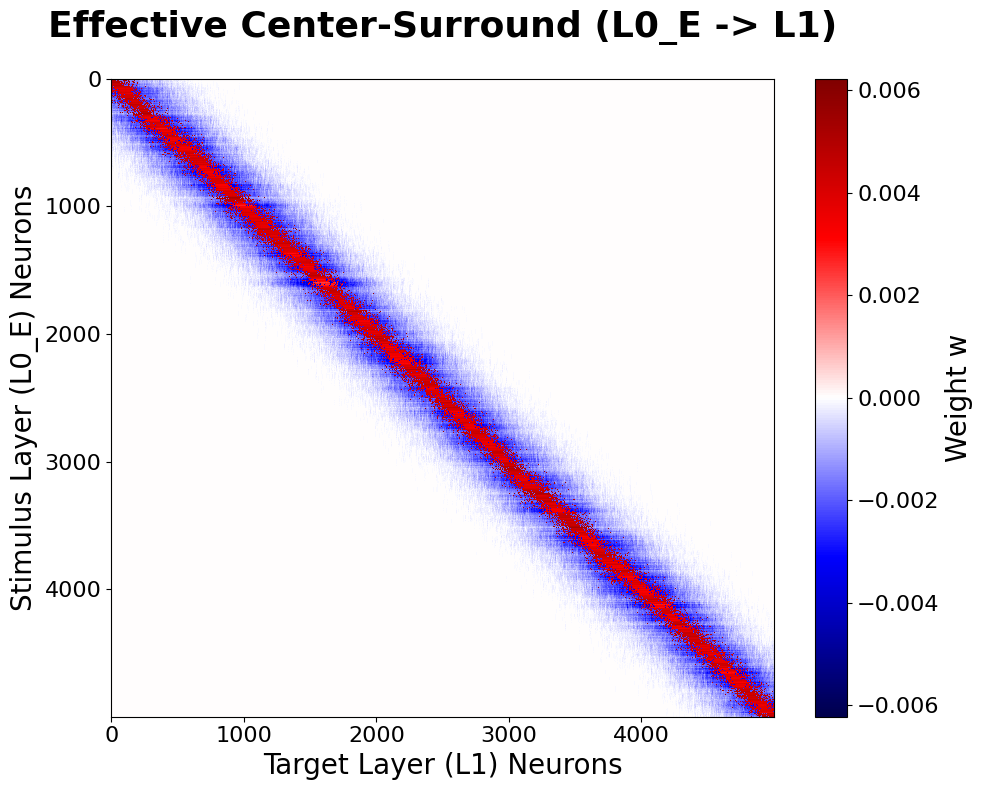

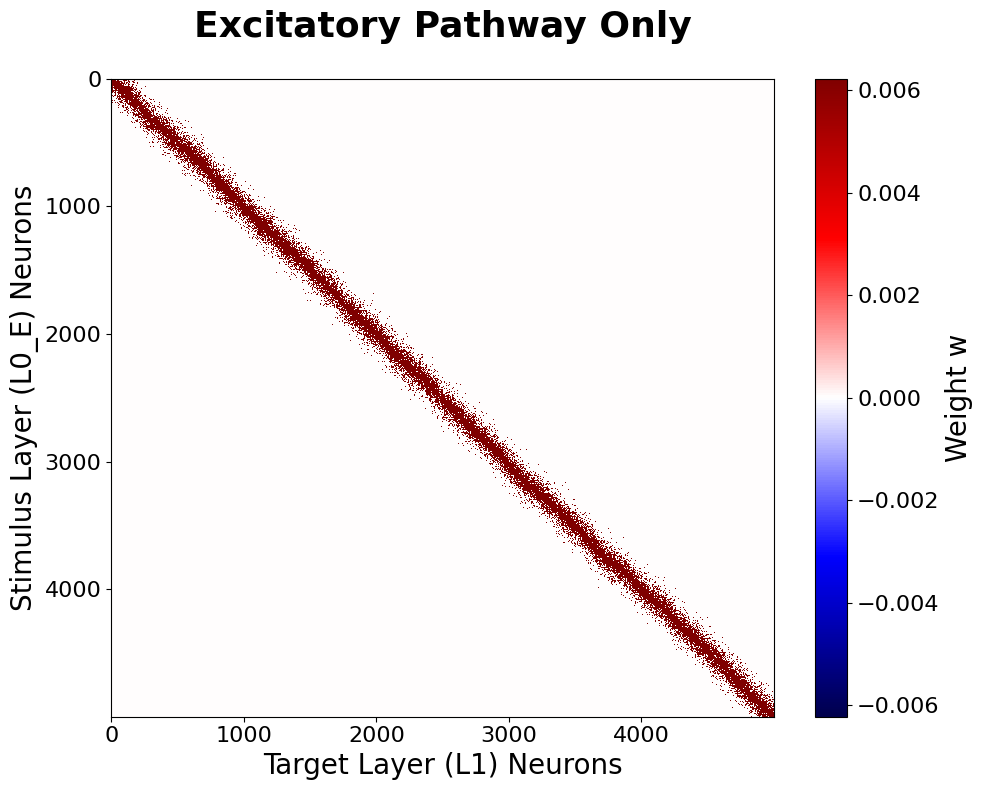

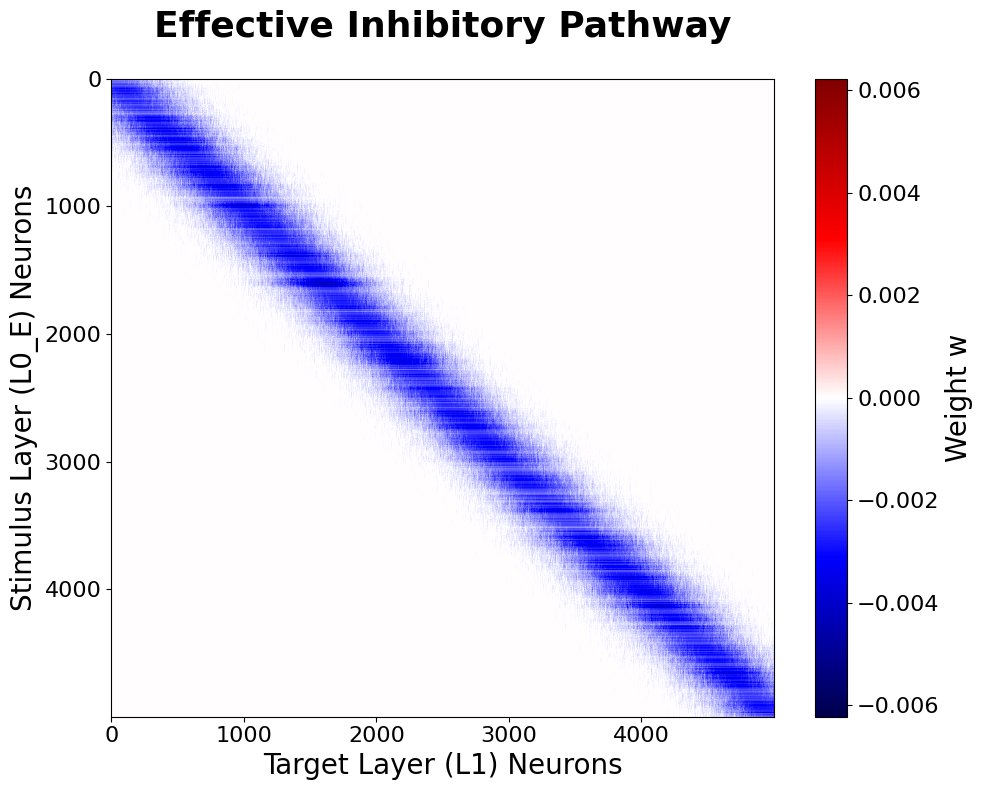

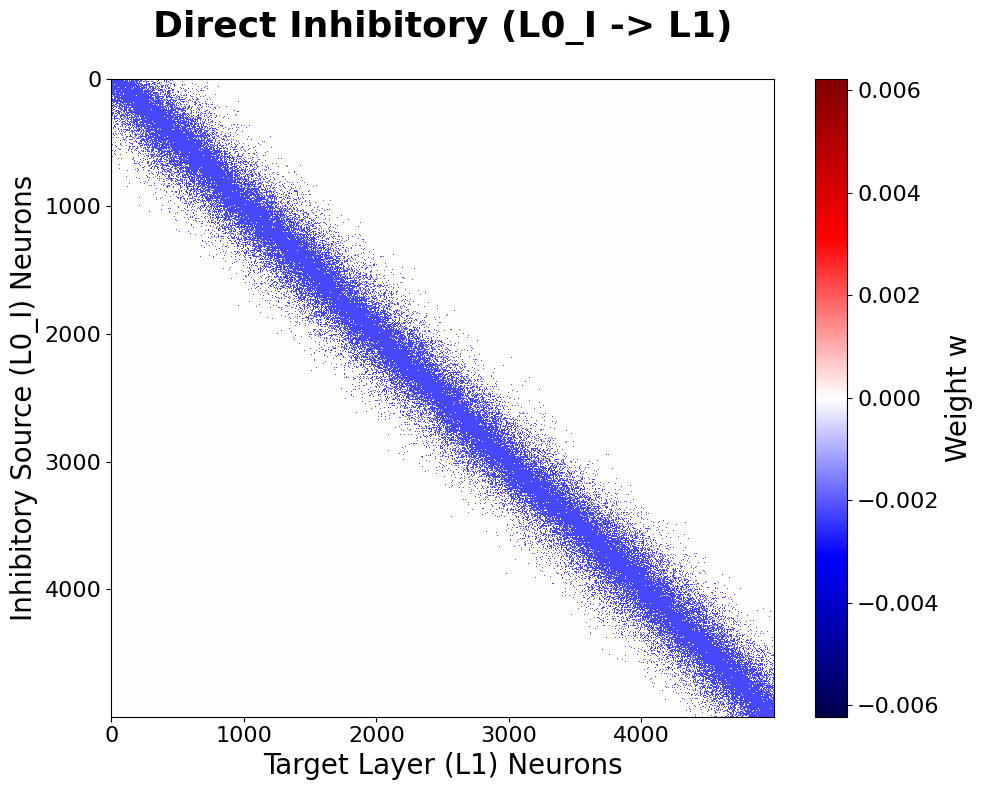

In [3]:
idx_r_E, idx_l_1 = get_sort_indices(r_vals_L0_E, l_vals_L1)

W_0_sorted = W_0[np.ix_(idx_r_E, idx_l_1)]

max_w_total = np.max(np.abs(W_0_sorted))

plot_weights(W=W_0_sorted, 
             title='Effective Center-Surround (L0_E -> L1)', 
             xlabel='Target Layer (L1) Neurons', 
             ylabel='Stimulus Layer (L0_E) Neurons', 
             cbar_label='Weight w', cmap='seismic', vmin=-max_w_total, vmax=max_w_total)

W_E_sorted = W_E[np.ix_(idx_r_E, idx_l_1)]
max_w_e = np.max(np.abs(W_E_sorted))

plot_weights(W=W_E_sorted, 
             title='Excitatory Pathway Only', 
             xlabel='Target Layer (L1) Neurons', 
             ylabel='Stimulus Layer (L0_E) Neurons', 
             cbar_label='Weight w', cmap='seismic', vmin=-max_w_total, vmax=max_w_total)

W_I_sorted = W_I[np.ix_(idx_r_E, idx_l_1)]
max_w_i = np.max(np.abs(W_I_sorted))

plot_weights(W=W_I_sorted, 
             title='Effective Inhibitory Pathway', 
             xlabel='Target Layer (L1) Neurons', 
             ylabel='Stimulus Layer (L0_E) Neurons', 
             cbar_label='Weight w', cmap='seismic', vmin=-max_w_total, vmax=max_w_total)

idx_r_I, _ = get_sort_indices(r_vals_L0_I, l_vals_L1)
W_I_block_sorted = W_I_block[np.ix_(idx_r_I, idx_l_1)]
max_w_i_block = np.max(np.abs(W_I_block_sorted))

plot_weights(W=W_I_block_sorted, 
             title='Direct Inhibitory (L0_I -> L1)', 
             xlabel='Target Layer (L1) Neurons', 
             ylabel='Inhibitory Source (L0_I) Neurons', 
             cbar_label='Weight w', cmap='seismic', vmin=-max_w_total, vmax=max_w_total)

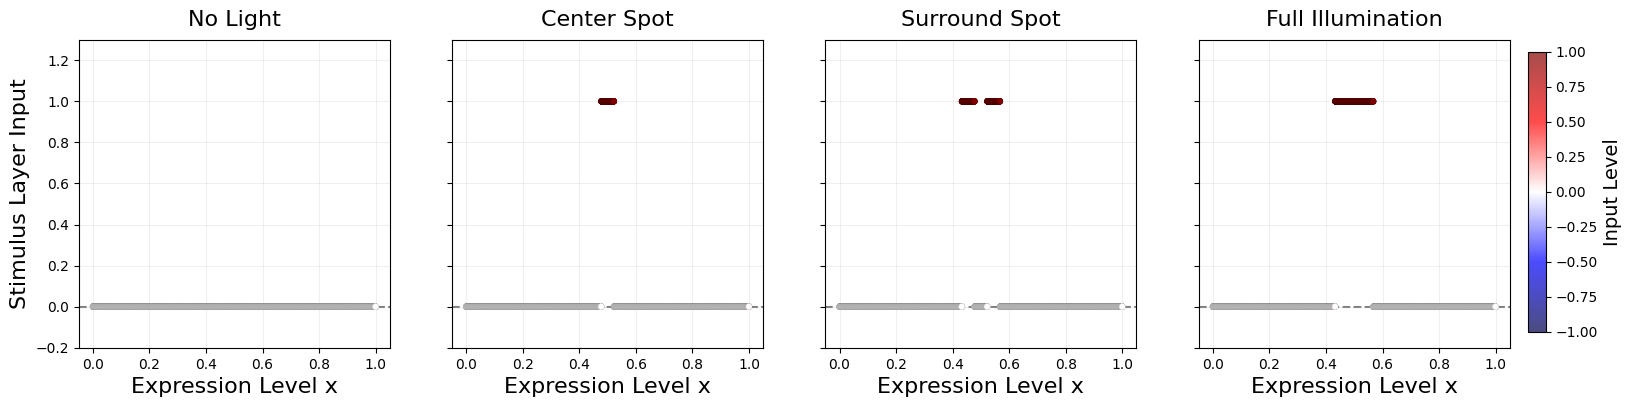

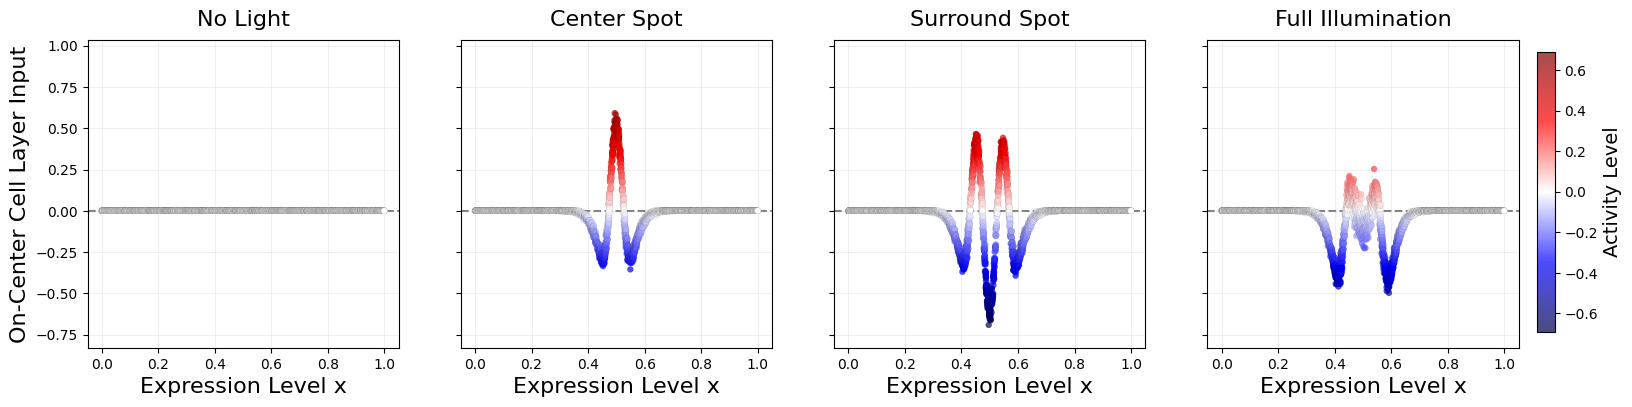

In [4]:
#############################
#      Stimulus Setup       #
#############################
stimuli = []
center_pos = 0.5

# 1. No Light
stimuli.append(("No Light", np.zeros(N_L0_E)))

# 2. Center Spot
stim_center = np.zeros(N_L0_E)
width_center = 1.5 * sig_E
stim_center[(coords_L0_E >= center_pos - width_center) & (coords_L0_E <= center_pos + width_center)] = 1.0
stimuli.append(("Center Spot", stim_center))

# 3. Surround Illumination 
stim_full = np.zeros(N_L0_E)
width_full = 1.5 * sig_I
stim_full[(coords_L0_E >= center_pos - width_full) & (coords_L0_E <= center_pos + width_full)] = 1.0
stim_surround = np.clip(stim_full - stim_center, 0, 1)
stimuli.append(("Surround Spot", stim_surround))

# 4. Full Illumination 
stimuli.append(("Full Illumination", stim_full))


#############################
#    Plot Network Activity  #
#############################


results = []

sort_idx_L1 = np.argsort(l_vals_L1)
x_L1_sorted = l_vals_L1[sort_idx_L1]

for col, (condition_name, A0) in enumerate(stimuli):
    A1 = W_0.T @ A0  
    
    A1_sorted = A1[sort_idx_L1]
    
    results.append({
        'name': condition_name,
        'A0': A0,
        'A1_sorted': A1_sorted
    })

limit_c_L0 = 1.0
x_limits = (-0.05, 1.05)
y_limits_L0 = (-0.2, 1.3)

fig1, axes1 = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
fig1.suptitle("", fontsize=16, fontweight='bold', y=1.00)

for col, res in enumerate(results):
    sc1 = axes1[col].scatter(coords_L0_E, res['A0'], c=res['A0'], cmap='seismic', vmin=-limit_c_L0, vmax=limit_c_L0, 
                             edgecolor='black', linewidth=0.05, s=20, zorder=2, alpha=0.7)
    axes1[col].set_title(res['name'], fontsize=16, pad=10)
    axes1[col].set_ylim(y_limits_L0)
    axes1[col].set_xlim(x_limits)
    axes1[col].axhline(0, color='black', linestyle='--', alpha=0.5, zorder=0)
    axes1[col].grid(True, alpha=0.2)
    axes1[col].set_xlabel("Expression Level x", fontsize=16)

axes1[0].set_ylabel("Stimulus Layer Input", fontsize=16)

fig1.subplots_adjust(right=0.92) 
cbar_ax1 = fig1.add_axes([0.93, 0.15, 0.01, 0.7]) 
cbar1 = fig1.colorbar(sc1, cax=cbar_ax1)
cbar1.set_label('Input Level', fontsize=14)

plt.show()


fig2, axes2 = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
fig2.suptitle("", fontsize=16, fontweight='bold', y=1.00)

max_a1 = max([np.max(np.abs(res['A1_sorted'])) for res in results])
limit_c_L1 = max_a1 if max_a1 > 0 else 1.0
y_limits_L1 = (-limit_c_L1 * 1.2, limit_c_L1 * 1.5)

for col, res in enumerate(results):
    sc2 = axes2[col].scatter(x_L1_sorted, res['A1_sorted'], c=res['A1_sorted'], cmap='seismic', vmin=-limit_c_L1, vmax=limit_c_L1, 
                             edgecolor='black', linewidth=0.05, s=20, zorder=2, alpha=0.7)
    axes2[col].set_title(res['name'], fontsize=16, pad=10)
    axes2[col].set_ylim(y_limits_L1)
    axes2[col].set_xlim(x_limits)
    axes2[col].axhline(0, color='black', linestyle='--', alpha=0.5, zorder=0)
    axes2[col].grid(True, alpha=0.2)
    axes2[col].set_xlabel("Expression Level x", fontsize=16)

axes2[0].set_ylabel("On-Center Cell Layer Input", fontsize=16)

fig2.subplots_adjust(right=0.92)
cbar_ax2 = fig2.add_axes([0.93, 0.15, 0.01, 0.7]) 
cbar2 = fig2.colorbar(sc2, cax=cbar_ax2)
cbar2.set_label('Activity Level', fontsize=14)

plt.show()

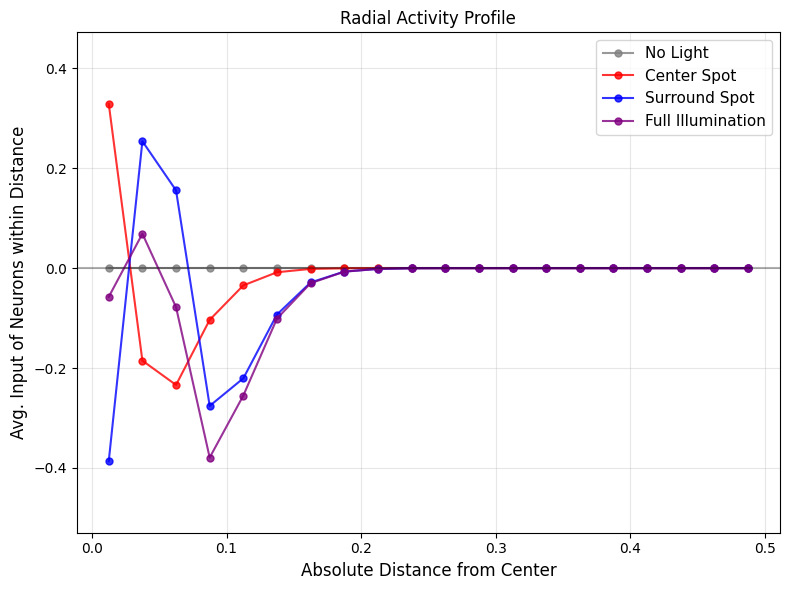

In [5]:
plot_standalone_radial_activity(stimuli, W_0, l_vals_L1)